# 1. T-test and p-values

The **purpose** is to visualize the relationship between data and a statistical test, not to focus on the code.

Follow the workbook to the end and only then change the code.


This is a simple script, which generates random data, plots it and runs a t-test.

First, we set things up. We install and load the beeswarm package and then set up
some plotting parameters. You do not need to worry about this.

> **Terms**
>
> - **Signal** — how far apart the two group means are.
> - **Noise** — how scattered the individual measurements are within each group (the standard deviation).
> - **t-statistic** — roughly signal divided by noise: how many standard errors separate the two means.
> - **p-value** — *if the two groups really came from the same distribution*, how often would a
>   difference at least this large turn up by chance? A small p-value means the data would be
>   surprising if there were no real difference.
> - **Significant** — conventionally p < 0.05. That is a convention, not a law of nature.

The point of the whole notebook is that the p-value depends on **three** things — the size of the
difference, the amount of scatter, and the number of measurements — and that you can change any of
them. Keep that in mind when you get to the questions.

In [1]:
install.packages("beeswarm")   # a plotting package; downloads from the internet, takes a minute
library(beeswarm)              # load it, so its functions are available below
rm(list = ls())                # clear anything left in memory from earlier runs

set.seed(44)                   # fix the random number generator, so everyone gets the same "random" data

# plotting stuff
# Margins around the plot from left to clockwise
# Roughly corresponds to inches of whitespace around the plot
par(mar = c(3.,2.7,1.3,1))
# The font is roughly times new roman
par(family="serif")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



We now set up the parameters of the simulated data for set 1 and 2.
n is the number of points, average is the mean, and stdev is the standard deviation.

We then build the random data with rnorm(). This function generates a vector of normally distributed data. We next collect these into a data frame.

Note how this data frame now has a grouping variable (A and B) matching the two random vectors.

In [2]:
# parameters — these five numbers are the whole experiment. Change them later, not now.
n1=30                          # how many measurements in set A
average1=50                    # the true mean of set A
stdev1=10                      # the true spread (standard deviation) of set A

n2=30                          # the same three numbers for set B
average2=60
stdev2=10

# random data sets — rnorm() draws n numbers from a normal distribution with that mean and spread.
# This is our stand-in for going into the lab and measuring 30 samples per group.
randVec1=rnorm(n = n1,mean = average1,sd = stdev1)
randVec2=rnorm(n = n2,mean = average2,sd = stdev2)

# Collecting into a dataframe: one column of values (y) and one column saying which set each came from (x)
DF=data.frame(
  x=factor(c(rep("A",n1), rep("B",n2))),
  y=c(randVec1, randVec2)
)

head(DF)                       # print the first six rows, to see what we built

,x,y
,<fct>,<dbl>
1,A,56.53918
2,A,50.19052
3,A,31.50496
4,A,48.67237
5,A,38.01182
6,A,36.70259


> **If you re-run the cell above on its own, you get different numbers.**
>
> `set.seed(44)` lives in the setup cell, so it only takes effect when that cell runs. When you
> change a parameter later and want to compare fairly, re-run the setup cell first — otherwise you
> have changed the parameter *and* drawn a new random sample, and you cannot tell which caused what.

We now plot the data with the beeswarm package, a nice way to show a lot of data. We also add segments to show both the means and the standard deviations to the plots.

We next add probability distributions to the plots.

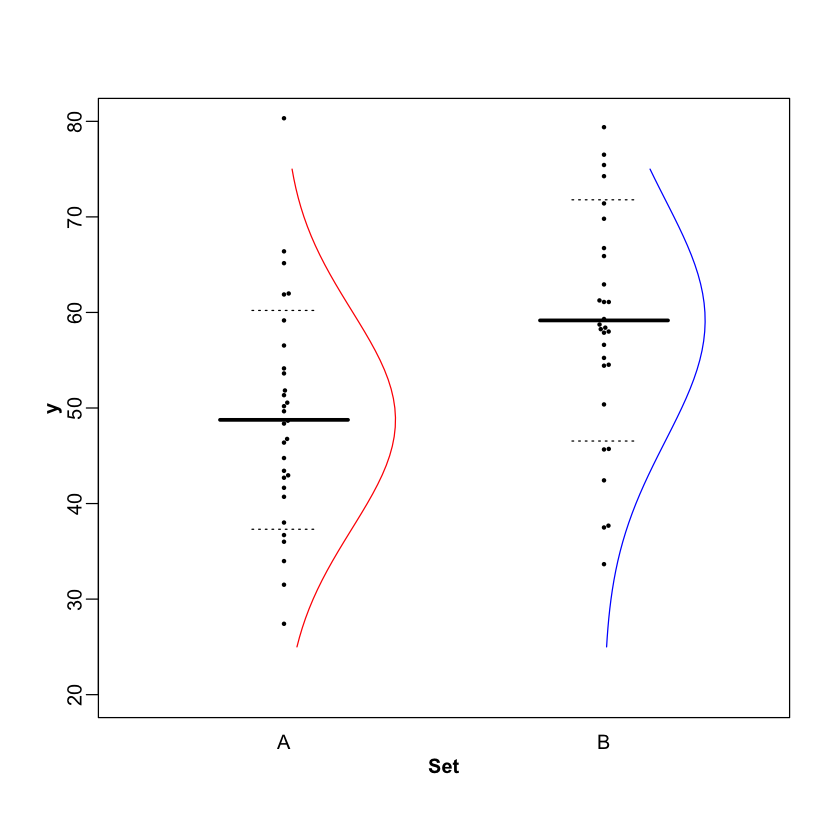

In [3]:

# A nice way to plot: beeswarm puts one dot per measurement and nudges them sideways
# so that overlapping points stay visible. Nothing is averaged away.
beeplot=beeswarm( data.frame(A=randVec1,B=randVec2),ylim=c(20,80),pch=16, cex=0.5,
                  xlab="Set",ylab="y",mgp = c(1.5, 0.5, 0) ,  font.lab=2 )

# plotting means — a thick horizontal line through each cloud of points
segments(0.8,mean(randVec1),1.2,mean(randVec1),lwd=3)
segments(1.8,mean(randVec2),2.2,mean(randVec2),lwd=3)

# standard deviations — dotted lines one SD above and below each mean.
# The gap between the thick lines is the SIGNAL; the height of each dotted band is the NOISE.
segments(0.9,mean(randVec1)+sd(randVec1),1.1,mean(randVec1)+sd(randVec1),lwd=1,lty="dotted")
segments(0.9,mean(randVec1)-sd(randVec1),1.1,mean(randVec1)-sd(randVec1),lwd=1,lty="dotted")
segments(1.9,mean(randVec2)+sd(randVec2),2.1,mean(randVec2)+sd(randVec2),lwd=1,lty="dotted")
segments(1.9,mean(randVec2)-sd(randVec2),2.1,mean(randVec2)-sd(randVec2),lwd=1,lty="dotted")


# calculating the probability curves — dnorm() gives the height of the bell curve
# at each value from 25 to 75, using the mean and SD we measured from the data
probCurve1=dnorm(25:75, mean(randVec1), sd = sd(randVec1))
probCurve2=dnorm(25:75, mean(randVec2), sd = sd(randVec2))

# probability distributions — drawn sideways next to each set.
# The "1+" and "2+" put each curve at its set's x position; the "10*" just makes it wide enough to see.
lines(y=25:75, x=1+10*probCurve1, col="red")
lines(y=25:75, x=2+10*probCurve2, col="blue")

**Before you run the test:** look at the plot. Would you consider the values of B to be higher
than A? Commit to an answer — you are about to find out whether a statistical test agrees with your
eye.

Lastly, we run the t-test.

The output has four things worth reading: **t** (the signal-to-noise ratio), **df** (degrees of
freedom, here n1 + n2 − 2), the **p-value**, and the **95% confidence interval** — the range of true
differences that would be compatible with this data. The confidence interval is often more useful
than the p-value, because it is in the units you measured.

In [4]:
# the t-test
# var.equal = TRUE assumes both sets have the same spread. That is true here by construction
# (we set stdev1 = stdev2 = 10). R's default is Welch's test, which does not assume it.
ttest=t.test(randVec1,randVec2, var.equal = TRUE);

print(ttest)


	Two Sample t-test

data:  randVec1 and randVec2
t = -3.3444, df = 58, p-value = 0.00145
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -16.634267  -4.177668
sample estimates:
mean of x mean of y 
 48.75963  59.16560 



**Question 1.1**

The t-test has tested if the mean of A is significantly different from the mean of B. Focus on the p-value - does it suggest a significant difference? Does it agree with your inspection of the plot?

**Question 1.2**
Now return to the code determining the parameters of the two vectors above. Imagine that 'average2' is now only 52 - is the test still significant? What happened? Did you change the signal or the noise?
What happens if we increase the 'n', does that change the signal or the noise?

**Question 1.3**

Set `average2` to 50, so that both sets now come from *exactly the same* distribution — there is no
real difference to find. Re-run the setup cell, the data cell and the t-test.

Now change `set.seed(44)` to another number and do it again. Repeat five or six times, and write
down the p-value each time. How much does it move? Do you ever get a p-value below 0.05 even though
you know there is nothing to find?

What does that tell you about a single p-value from a single experiment?

---

# 2. Many tests at once

So far we ran **one** test. Real experiments are rarely like that: a proteomics run compares
thousands of proteins between two conditions, and each protein gets its own t-test.

That changes everything. A p-value of 0.05 means "this would happen 1 time in 20 by chance".
Run 100 tests on data with no real differences at all and you should *expect* about 5 significant
results — all of them wrong. The tests are fine; the problem is how many of them you ran.

Below we simulate a small experiment: **100 proteins**, measured in 10 control and 10 treated
samples. We build it so that exactly **10 proteins are genuinely different** and the other 90 are
not. Because we made the data, we know the right answer — which means we can count our mistakes.

In [5]:
set.seed(7)                    # so everyone gets the same dataset

nProteins = 100                # how many proteins we "measured"
nTrue     = 10                 # how many are genuinely different between the groups
nPerGroup = 10                 # replicates per group

# One row per protein, one column per sample. Both groups start from the same distribution,
# so at this point NO protein is truly different.
control = matrix(rnorm(nProteins*nPerGroup, mean = 50, sd = 10), nrow = nProteins)
treated = matrix(rnorm(nProteins*nPerGroup, mean = 50, sd = 10), nrow = nProteins)

# Now make the first 10 proteins genuinely higher in the treated group — this is the real signal.
treated[1:nTrue, ] = treated[1:nTrue, ] + 20

# Keep a record of which proteins we made different, so we can check our answers later.
isTrulyDifferent = c(rep(TRUE, nTrue), rep(FALSE, nProteins - nTrue))

cat("dataset:", nProteins, "proteins,", nPerGroup, "samples per group,",
    nTrue, "of them genuinely different\n")

dataset: 100 proteins, 10 samples per group, 10 of them genuinely different


Now one t-test per protein — the same `t.test()` as in part 1, just run 100 times in a loop.
We collect the 100 p-values and look at them together.

proteins with p < 0.05:         11 


  of which genuinely different: 9 


  of which are false positives: 2 


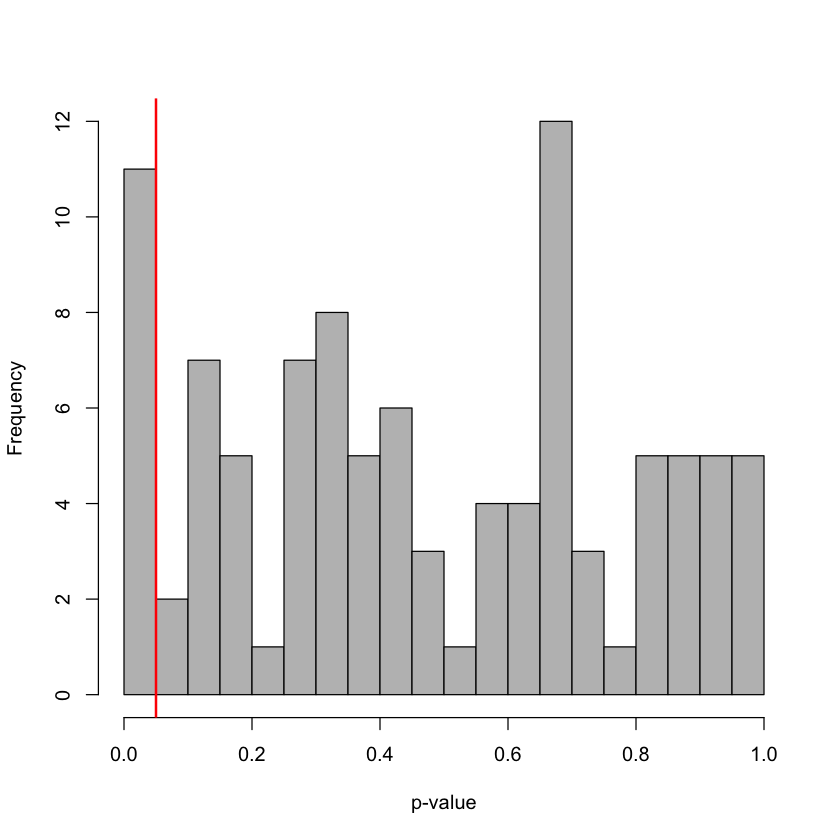

In [6]:
pvals = numeric(nProteins)               # an empty vector to store the 100 p-values

for (i in 1:nProteins) {                 # loop over the proteins, one row at a time
  pvals[i] = t.test(control[i,], treated[i,], var.equal = TRUE)$p.value
}

# The distribution of p-values tells you a lot. Real effects pile up near zero;
# proteins with no real difference give p-values spread evenly between 0 and 1.
hist(pvals, breaks = 20, col = "grey", xlab = "p-value", main = "")
abline(v = 0.05, col = "red", lwd = 2)   # the usual 0.05 cutoff

cat("proteins with p < 0.05:        ", sum(pvals < 0.05), "\n")
cat("  of which genuinely different:", sum(pvals < 0.05 &  isTrulyDifferent), "\n")
cat("  of which are false positives:", sum(pvals < 0.05 & !isTrulyDifferent), "\n")

Some of those "hits" are proteins we know are identical between the groups. That is the cost of
running 100 tests.

Two standard ways to correct for it, both available in R through `p.adjust()`:

- **Bonferroni** — multiply every p-value by the number of tests. It controls the chance of making
  *even one* false claim. Very safe, and it throws away real findings along with the false ones.
- **Benjamini–Hochberg (BH)** — control the *proportion* of your hits that are wrong (the false
  discovery rate). If you accept that roughly 5% of your list will be wrong, you keep far more of
  the real signal. This is what genomics and proteomics papers normally use.

In [7]:
pBonf = p.adjust(pvals, method = "bonferroni")   # strict: no false positives at all, if possible
pBH   = p.adjust(pvals, method = "BH")           # lenient: a controlled fraction of false positives

# Count, for each approach, how many proteins we would report and how many of those are wrong.
results = data.frame(
  method      = c("no correction", "Bonferroni", "BH (FDR)"),
  reported    = c(sum(pvals < 0.05),
                  sum(pBonf < 0.05),
                  sum(pBH   < 0.05)),
  trueFinds   = c(sum(pvals < 0.05 &  isTrulyDifferent),
                  sum(pBonf < 0.05 &  isTrulyDifferent),
                  sum(pBH   < 0.05 &  isTrulyDifferent)),
  falseFinds  = c(sum(pvals < 0.05 & !isTrulyDifferent),
                  sum(pBonf < 0.05 & !isTrulyDifferent),
                  sum(pBH   < 0.05 & !isTrulyDifferent)),
  missed      = c(nTrue - sum(pvals < 0.05 & isTrulyDifferent),
                  nTrue - sum(pBonf < 0.05 & isTrulyDifferent),
                  nTrue - sum(pBH   < 0.05 & isTrulyDifferent))
)

print(results)

         method reported trueFinds falseFinds missed
1 no correction       11         9          2      1
2    Bonferroni        4         4          0      6
3      BH (FDR)        9         9          0      1


**Question 2.1**

Look at the histogram. Which part of it is the 10 real effects, and which part is the 90 proteins
with nothing going on? How would the histogram look if *none* of the proteins were different?

**Question 2.2**

Read the table. Going from no correction to Bonferroni to BH, what happens to the number of false
findings — and what do you pay for it? Which of the three would you use for an experiment whose
hits you are going to follow up in the lab, one protein at a time? Which for a screen where you
just want a shortlist?

**Question 2.3**

Change `nProteins` to 1000, keeping `nTrue` at 10, and run part 2 again. The experiment is exactly
as good as before for each individual protein — but what happens to the uncorrected result, and
what happens to Bonferroni? What does that tell you about measuring more things at once?